# Gamma Scalping and Volatility Analysis (Practical Base-Case Backtest)

## 1. Project Objective

This notebook implements and evaluates a delta-hedged SPX straddle strategy using E-mini S&P 500 (ES) futures as the hedge instrument.

The analysis focuses on how gamma gains, theta decay, implied versus realised (subsequently) volatility and transaction costs interact to determine strategy P&L (profit and loss).

This version of the model makes three changes relative to the theoretical benchmark: 

1) Fractional ES are no longer used, ES contracts must be an integer value.
2) Realistic commissions are implemented.
3) Bid-ask spread and slippage are modelled.

Executable hedge timing was considered but not implemented 

In [1]:
# ES Gamma Scalping (Daily) — March 10–20, 2020

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

In [2]:
plt.rcParams["figure.figsize"] = (10, 4) # set as default plot size

## 2. Model Configuration

This strategy models a long SPX straddle dynamically delta-hedged using E-mini S&P 500 futures. The configuration below defines the contract specifications, hedge rules, option assumptions, transaction costs and backtest period:

- $1.25 commission per ES contract per side
- 1 tick total execution friction = 0.25 ES points = $12.50 per contract per side. THis comprises half a tick spread crossing & half a tick slippage.

Contract-specific March and June ES futures are represented separately. This allows the hedge roll to be handled explicitly without altering strategy mechanics.

In [3]:
# Contract specifications
SPX_OPTION_MULTIPLIER = 100.0
ES_POINT_VALUE        = 50.0

# ES execution-friction assumptions.
# One ES tick is 0.25 index points = $12.50 per contract.
ES_TICK_SIZE = 0.25

# Base-case executable assumption:
# half a tick for crossing the bid-ask spread plus
# half a tick of additional adverse slippage.
ES_HALF_SPREAD_TICKS = 0.5
ES_SLIPPAGE_TICKS = 0.5

ES_EXECUTION_FRICTION_POINTS = (
    ES_HALF_SPREAD_TICKS
    + ES_SLIPPAGE_TICKS
) * ES_TICK_SIZE

# Daily-frequency hedge-timing convention.
#
# SPX and VIX9D are observed as daily closing inputs. Their closing
# conventions are not perfectly synchronous, so the model does not
# assign a precise intraday timestamp to the combined hedge signal
# or to the resulting ES transaction.
#
# The ES position held entering each observation earns that
# interval's settlement-to-settlement futures P&L. Any hedge
# decision based on the current closing state is applied only
# afterwards and becomes the position carried into the next interval.

# Strategy specification
N_STRADDLES           = 1
DELTA_REHEDGE_BAND    = 0.10
# All-in explicit institutional ES trading cost:
# exchange, clearing and brokerage, per contract per side.
ES_COMMISSION_PER_CONTRACT_SIDE = 1.25

# Option assumptions
RISK_FREE_RATE        = 0.0
OPTION_EXPIRY         = pd.Timestamp("2020-03-20")
STRIKE_INTERVAL       = 5.0

# Market data
SPX_TICKER            = "^GSPC"
VOL_TICKER            = "^VIX9D"

# Contract-specific ES hedge data
ES_MARCH_CONTRACT     = "ESH20"
ES_JUNE_CONTRACT      = "ESM20"
ES_ROLL_DATE          = pd.Timestamp("2020-03-12")
ES_DATA_FILE          = "Data/es_futures_mar2020.csv"

# Backtest period
INTERVAL              = "1d"
START                 = "2020-03-10"
END                   = "2020-03-21"  # yfinance end date is exclusive

## 3. Data collection and preparation

SPX and short-dated implied-volatility observations (VIX9D) are aligned with contract-specific March and June 2020 E-mini S&P 500 futures data over the backtest period. SPX provides underlying level for the options position and ES provides the hedge instrument.

The straddle strike is fixed at inception. Time to expiry declines throughout the option life. Official CME settlement prices are used as the daily ES hedge mark as they are available consistently for both contracts across the backtest window. 

March and June contracts remain separate around the roll. On the roll date, hedge P&L is calculated using the contract held over the preceding interval, before the roll into the new contract.

In [4]:
def download_close_series(ticker, column_name):
    
    raw = yf.download(
        ticker,
        start=START,
        end=END,
        interval=INTERVAL,
        auto_adjust=False,
        progress=False,
    )

    if raw is None or raw.empty:
        raise RuntimeError(f"No data returned for {ticker}.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" not in raw.columns.get_level_values(0):
            raise RuntimeError(f"No Close column returned for {ticker}.")

        close = raw["Close"]

        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]

    else:
        if "Close" not in raw.columns:
            raise RuntimeError(f"No Close column returned for {ticker}.")

        close = raw["Close"]

    close = pd.to_numeric(
        close,
        errors="coerce"
    ).dropna()

    close.name = column_name
    close.index = pd.to_datetime(close.index)

    if close.index.tz is not None:
        close.index = close.index.tz_localize(None)

    close.index = close.index.normalize()

    return close.sort_index()

In [5]:
def load_es_contract_data(filepath):

    es_data = pd.read_csv(
        filepath,
        parse_dates=["Date"],
    )

    required_columns = [
        "Date",
        "ESH20_Settlement",
        "ESM20_Settlement",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in es_data.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Missing required ES data columns: "
            + ", ".join(missing_columns)
        )

    es_data = (
        es_data
        .set_index("Date")
        .sort_index()
    )

    es_data.index = (
        pd.to_datetime(es_data.index)
        .tz_localize(None)
        .normalize()
    )

    if es_data.index.has_duplicates:
        raise RuntimeError(
            "Duplicate dates found in the ES futures dataset."
        )

    # Convert all available ES data fields to numeric values while
    # retaining optional volume and open-interest columns if present.
    es_data = es_data.apply(
        pd.to_numeric,
        errors="coerce",
    )

    settlement_columns = [
        "ESH20_Settlement",
        "ESM20_Settlement",
    ]

    if es_data[settlement_columns].isna().any().any():
        raise RuntimeError(
            "Missing ES settlement observations found."
        )

    return es_data

In [6]:
# Download the market series used by the option model.
spx = download_close_series(
    SPX_TICKER,
    "SPX",
)

vol_proxy = download_close_series(
    VOL_TICKER,
    "VIX9D",
)

# Load the locally prepared contract-specific ES settlement data.
es_contracts = load_es_contract_data(
    ES_DATA_FILE
)

# Align the option and hedge inputs to common trading dates.
market = pd.concat(
    [
        spx,
        vol_proxy,
        es_contracts,
    ],
    axis=1,
    join="inner",
).dropna(
    subset=["SPX", "VIX9D"]
).sort_index()

market = market.loc[
    (market.index >= pd.Timestamp(START))
    & (market.index <= OPTION_EXPIRY)
].copy()

if market.empty:
    raise RuntimeError(
        "No common market observations remain after aligning the input datasets."
    )

# The theoretical backtest requires observations at both inception and expiry.
backtest_start = pd.Timestamp(START).normalize()
option_expiry = OPTION_EXPIRY.normalize()

if backtest_start not in market.index:
    raise RuntimeError(
        "Backtest-start observation is missing from the aligned market dataset."
    )

if option_expiry not in market.index:
    raise RuntimeError(
        "Option-expiry observation is missing from the aligned market dataset."
    )

# Validate the underlying and implied-volatility proxy inputs.
if (market["SPX"] <= 0).any():
    raise RuntimeError(
        "SPX contains non-positive observations."
    )

market["iv_proxy"] = (
    market["VIX9D"] / 100.0
)

if (market["iv_proxy"] <= 0).any():
    raise RuntimeError(
        "VIX9D implied-volatility proxy contains non-positive observations."
    )

# Fix the straddle strike once at inception.
initial_spx = market["SPX"].iloc[0]

STRIKE = (
    round(initial_spx / STRIKE_INTERVAL)
    * STRIKE_INTERVAL
)

market["K"] = STRIKE

# Let time to expiry decline using calendar time.
market["days_to_expiry"] = (
    option_expiry
    - market.index
).days

market["T"] = (
    market["days_to_expiry"]
    / 365.0
)

if (market["T"] < 0).any():
    raise RuntimeError(
        "Market data extend beyond option expiry."
    )

# Treat the roll date as the close at which the hedge moves from March to June.
market["ES_contract"] = np.where(
    market.index < ES_ROLL_DATE,
    ES_MARCH_CONTRACT,
    ES_JUNE_CONTRACT,
)

market["is_roll_date"] = (
    market.index == ES_ROLL_DATE
)

market["ES_settlement"] = np.where(
    market.index < ES_ROLL_DATE,
    market["ESH20_Settlement"],
    market["ESM20_Settlement"],
)

# Calculate each hedge return within the contract actually held over that interval.
march_settlement_change = (
    market["ESH20_Settlement"].diff()
)

june_settlement_change = (
    market["ESM20_Settlement"].diff()
)

previous_contract = (
    market["ES_contract"].shift(1)
)

market["ES_settlement_change"] = np.select(
    [
        previous_contract.eq(ES_MARCH_CONTRACT),
        previous_contract.eq(ES_JUNE_CONTRACT),
    ],
    [
        march_settlement_change,
        june_settlement_change,
    ],
    default=np.nan,
)

# Retain SPX returns for later realised-volatility analysis.
market["SPX_log_return"] = np.log(
    market["SPX"]
    / market["SPX"].shift(1)
)

print(f"Backtest observations: {len(market)}")
print(f"Initial SPX level:      {initial_spx:.2f}")
print(f"Straddle strike:        {STRIKE:.0f}")
print(f"Option expiry:          {OPTION_EXPIRY.date()}")
print(f"ES roll date:           {ES_ROLL_DATE.date()}")

display(
    market[
        [
            "SPX",
            "VIX9D",
            "iv_proxy",
            "K",
            "days_to_expiry",
            "T",
            "ES_contract",
            "ES_settlement",
            "ES_settlement_change",
        ]
    ]
)

Backtest observations: 9
Initial SPX level:      2882.23
Straddle strike:        2880
Option expiry:          2020-03-20
ES roll date:           2020-03-12


,SPX,VIX9D,iv_proxy,K,days_to_expiry,T,ES_contract,ES_settlement,ES_settlement_change
Date,,,,,,,,,
2020-03-10,2882.229980,57.389999,0.5739,2880.0,10,0.027397,ESH20,2865.75,NaN
2020-03-11,2741.379883,68.209999,0.6821,2880.0,9,0.024658,ESH20,2740.25,-125.50
2020-03-12,2480.639893,103.559998,1.0356,2880.0,8,0.021918,ESM20,2456.00,-271.25
2020-03-13,2711.020020,69.870003,0.6987,2880.0,7,0.019178,ESM20,2684.00,228.00
2020-03-16,2386.129883,106.660004,1.0666,2880.0,4,0.010959,ESM20,2405.25,-278.75
2020-03-17,2529.189941,92.930000,0.9293,2880.0,3,0.008219,ESM20,2485.50,80.25
2020-03-18,2398.100098,97.220001,0.9722,2880.0,2,0.005479,ESM20,2401.50,-84.00
2020-03-19,2409.389893,91.019997,0.9102,2880.0,1,0.002740,ESM20,2389.00,-12.50
2020-03-20,2304.919922,83.470001,0.8347,2880.0,0,0.000000,ESM20,2288.50,-100.50


## 4. Option pricing and Greeks

Black-Scholes is used to value the call and put forming the long SPX straddle and to calculate the position's delta, gamma and theta at each observation.

Option values and Greeks are calculated in SPX index-point terms in this section. The SPX contract multiplier is applied later in the backtest when translating these exposures into dollar P&L and determining the required ES futures hedge.

At expiry, the call and put are valued at intrinsic value and the remaining gamma and theta exposures are set to zero. This avoids numerical instability as time to expiry approaches zero and allows the strategy to be evaluated using full Black-Scholes repricing, while the Greeks are retained for hedge construction and P&L attribution.

In [7]:
N = NormalDist(0, 1)


def normal_pdf(x):
    """Standard normal probability density function."""
    return np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)


def d1(S, K, r, sigma, T):
    """Black-Scholes d1 for a positive-volatility, pre-expiry option."""
    return (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (
        sigma * np.sqrt(T)
    )


def d2(S, K, r, sigma, T):
    """Black-Scholes d2."""
    return d1(S, K, r, sigma, T) - sigma * np.sqrt(T)


def call_price(S, K, r, sigma, T):
    """Black-Scholes European call value in index points."""
    if T <= 0:
        return max(S - K, 0.0)

    if sigma <= 0:
        return max(S - K * np.exp(-r * T), 0.0)

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        S * N.cdf(d1_)
        - K * np.exp(-r * T) * N.cdf(d2_)
    )


def put_price(S, K, r, sigma, T):
    """Black-Scholes European put value in index points."""
    if T <= 0:
        return max(K - S, 0.0)

    if sigma <= 0:
        return max(K * np.exp(-r * T) - S, 0.0)

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        K * np.exp(-r * T) * N.cdf(-d2_)
        - S * N.cdf(-d1_)
    )


def delta_call(S, K, r, sigma, T):
    """Call delta per index point."""
    if T <= 0:
        if S > K:
            return 1.0
        if S < K:
            return 0.0
        return 0.5

    if sigma <= 0:
        return 1.0 if S > K * np.exp(-r * T) else 0.0

    return N.cdf(
        d1(S, K, r, sigma, T)
    )


def delta_put(S, K, r, sigma, T):
    """Put delta per index point."""
    if T <= 0:
        if S > K:
            return 0.0
        if S < K:
            return -1.0
        return -0.5

    if sigma <= 0:
        return 0.0 if S > K * np.exp(-r * T) else -1.0

    return N.cdf(
        d1(S, K, r, sigma, T)
    ) - 1.0


def gamma_bs(S, K, r, sigma, T):
    """Black-Scholes gamma per index point."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1_ = d1(S, K, r, sigma, T)

    return normal_pdf(d1_) / (
        S * sigma * np.sqrt(T)
    )


def theta_call(S, K, r, sigma, T):
    """Annualised Black-Scholes call theta in index points."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        -(S * normal_pdf(d1_) * sigma)
        / (2.0 * np.sqrt(T))
        - r * K * np.exp(-r * T) * N.cdf(d2_)
    )


def theta_put(S, K, r, sigma, T):
    """Annualised Black-Scholes put theta in index points."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        -(S * normal_pdf(d1_) * sigma)
        / (2.0 * np.sqrt(T))
        + r * K * np.exp(-r * T) * N.cdf(-d2_)
    )


def straddle_metrics(S, K, sigma, T, n=1.0):
    """Return theoretical value and Greeks for a long SPX straddle."""

    call = call_price(
        S, K, RISK_FREE_RATE, sigma, T
    )

    put = put_price(
        S, K, RISK_FREE_RATE, sigma, T
    )

    call_delta = delta_call(
        S, K, RISK_FREE_RATE, sigma, T
    )

    put_delta = delta_put(
        S, K, RISK_FREE_RATE, sigma, T
    )

    gamma = gamma_bs(
        S, K, RISK_FREE_RATE, sigma, T
    )

    theta = (
        theta_call(
            S, K, RISK_FREE_RATE, sigma, T
        )
        + theta_put(
            S, K, RISK_FREE_RATE, sigma, T
        )
    )

    return {
        "call_price": n * call,
        "put_price": n * put,
        "straddle_price": n * (call + put),
        "delta": n * (call_delta + put_delta),
        "gamma": n * 2.0 * gamma,
        "theta": n * theta,
    }


def continuous_es_target(option_delta):
    """
    Continuous ES hedge required to offset the option's dollar delta exactly.

    Retained as a diagnostic benchmark only; it is not directly executable.
    """
    return (
        -option_delta
        * SPX_OPTION_MULTIPLIER
        / ES_POINT_VALUE
    )


def integer_es_target(option_delta):
    """
    Convert the continuous ES hedge into the nearest whole ES contract.

    Half-contract ties are rounded away from zero for deterministic behaviour.
    """
    continuous_target = continuous_es_target(
        option_delta
    )

    if continuous_target == 0:
        return 0

    return int(
        np.sign(continuous_target)
        * np.floor(abs(continuous_target) + 0.5)
    )

def es_commission(trade_qty):
    """
    Explicit institutional trading cost for an ES transaction.

    Commission is charged per whole contract per side.
    """
    return (
        abs(trade_qty)
        * ES_COMMISSION_PER_CONTRACT_SIDE
    )

test_metrics = straddle_metrics(
    S=market["SPX"].iloc[0],
    K=STRIKE,
    sigma=market["iv_proxy"].iloc[0],
    T=market["T"].iloc[0],
    n=N_STRADDLES,
)

def es_execution_cost(trade_qty):
    """
    Model bid-ask crossing and slippage for an executable ES trade.

    Execution friction is charged per whole contract per side and is
    kept separate from settlement-to-settlement futures hedge P&L.
    """
    return (
        abs(trade_qty)
        * ES_POINT_VALUE
        * ES_EXECUTION_FRICTION_POINTS
    )

test_metrics

{'call_price': np.float64(110.26193617742229),
 'put_price': np.float64(108.03195570867251),
 'straddle_price': np.float64(218.2938918860948),
 'delta': 0.0443748235203294,
 'gamma': np.float64(0.0029097072217441006),
 'theta': np.float64(-3980.6042209610096)}

## 5. Delta-hedged Gamma-scalping backtest

The backtest combines daily change in the modelled SPX straddle value with the P&L generated by an ES futures hedge.
The straddle is repriced at each observation using the Black-Scholes logic in section 4. The ES position held over each interval earns settlement-to-settlement futures P&L.

The option delta is converted into the ES position required for exact delta-neutrality (fractional):

$$
-\Delta_t^{option}\timeszfrac{100}{50}
$$

, where 100 is the SPX option multiplier and 50 is the ES dollars per index point.

This is retained as a benchmark - the actual hedge value is restricted to integer values, based on residual SPX-equivalent delta:

$$
\Delta_t^{option} + q_t^{ES}\times\frac{50}{100}
$$

, where (Q_t^{ES}) is the whole-contract ES position held pre-hedge decision. When absolute residual delta is > 0.10, this triggers the rehedge logic.

A granularity hold arises when the residual delta exceeds the configured band, but the nearest executable integer target in the same as the existing ES position. This is displayed as `GRANULARITY_HOLD`, so as to differentiate this from a standard `HOLD`, where the residual delta is within the rehedge band.

The position enterting each observation earns futures P&L for that settlement interval before the new hedge adjustment. The ES position arising from the rehedge is carried into the next interval. This prevents a current hedge decision from retrospectively affecting earlier futures P&L.

Where the active ES contract changes, existing contract is closed and the required position is reopened in the new contract. This means the roll is treated as two transactions, rather than a change in futures price exposure. 

ES transactions incur per-contract commissions bid-ask/slippage cost.

At option expiry, the straddle settles at intrinsic value and the ES hedge is closed. This leaves zero futues exposure.

In [8]:
def run_backtest(market):

    # Run the daily delta-hedged straddle backtest.
    records = []

    first_date = market.index[0]
    first_row = market.iloc[0]

    first_metrics = straddle_metrics(
        S=first_row["SPX"],
        K=first_row["K"],
        sigma=first_row["iv_proxy"],
        T=first_row["T"],
        n=N_STRADDLES,
    )

    # Retain the exact theoretical target for comparison, but trade only
    # the nearest whole ES contract.
    continuous_target = continuous_es_target(
        first_metrics["delta"]
    )

    integer_target = integer_es_target(
        first_metrics["delta"]
    )
    # The inception hedge is determined from the first daily closing
    # market state. No futures hedge P&L is attributed before this
    # initial hedge position is established.
    q_fut = integer_target

    entry_contracts_traded = abs(q_fut)

    entry_commission = es_commission(
        q_fut
    )

    entry_execution_cost = es_execution_cost(
        q_fut
    )

    net_delta_after = (
        first_metrics["delta"]
        + q_fut
        * ES_POINT_VALUE
        / SPX_OPTION_MULTIPLIER
    )

    records.append(
        {
            "Date": first_date,
            "SPX": first_row["SPX"],
            "VIX9D": first_row["VIX9D"],
            "straddle_price": first_metrics["straddle_price"],
            "delta": first_metrics["delta"],
            "gamma": first_metrics["gamma"],
            "theta": first_metrics["theta"],
            "ES_contract": first_row["ES_contract"],
            "ES_settlement_change": np.nan,
            "continuous_es_target": continuous_target,
            "integer_es_target": integer_target,
            "net_delta_before": first_metrics["delta"],
            "net_delta_after": net_delta_after,
            "q_fut_start": 0,
            "q_fut_end": q_fut,
            "contracts_traded": entry_contracts_traded,
            "option_pnl": 0.0,
            "hedge_pnl": 0.0,
            "commission": entry_commission,
            "execution_cost": entry_execution_cost,
            "total_pnl": (
                -entry_commission
                -entry_execution_cost
            ),
            "delta_attribution": 0.0,
            "gamma_attribution": 0.0,
            "theta_attribution": 0.0,
            "option_residual": 0.0,
            "event": "OPEN",
        }
    )

    prev_date = first_date
    prev_row = first_row
    prev_metrics = first_metrics
    prev_contract = first_row["ES_contract"]

    for ts, row in market.iloc[1:].iterrows():
        metrics = straddle_metrics(
            S=row["SPX"],
            K=row["K"],
            sigma=row["iv_proxy"],
            T=row["T"],
            n=N_STRADDLES,
        )

        # Reprice the theoretical SPX straddle.
        option_pnl = (
            metrics["straddle_price"]
            - prev_metrics["straddle_price"]
        ) * SPX_OPTION_MULTIPLIER

        if pd.isna(row["ES_settlement_change"]):
            raise RuntimeError(
                f"Missing ES settlement change for {ts.date()}."
            )

        # The ES position carried from the previous observation is held
        # through the current settlement interval and therefore earns the
        # full settlement-to-settlement futures P&L ending today.
        #
        # Any hedge decision based on the current daily closing state is
        # applied only after this interval P&L has been attributed.
        q_fut_start = q_fut

        hedge_pnl = (
            q_fut_start
            * ES_POINT_VALUE
            * row["ES_settlement_change"]
        )

        # Attribute the option-price change using previous-period Greeks.
        dS = row["SPX"] - prev_row["SPX"]
        dt_year = (ts - prev_date).days / 365.0

        delta_attribution = (
            prev_metrics["delta"]
            * SPX_OPTION_MULTIPLIER
            * dS
        )

        gamma_attribution = (
            0.5
            * prev_metrics["gamma"]
            * SPX_OPTION_MULTIPLIER
            * dS**2
        )

        theta_attribution = (
            prev_metrics["theta"]
            * SPX_OPTION_MULTIPLIER
            * dt_year
        )

        option_residual = (
            option_pnl
            - delta_attribution
            - gamma_attribution
            - theta_attribution
        )

        # Today's hedge decision is based on closing inputs of VIX9D and SPX.
        # Residual SPX-equivalent delta is measured using the ES position still held before any hedge adjustment.
        net_delta_before = (
            metrics["delta"]
            + q_fut_start
            * ES_POINT_VALUE
            / SPX_OPTION_MULTIPLIER
        )

        continuous_target = continuous_es_target(
            metrics["delta"]
        )

        integer_target = integer_es_target(
            metrics["delta"]
        )

        q_target = q_fut_start
        contracts_traded = 0
        commission = 0.0
        execution_cost = 0.0
        event = "HOLD"

        contract_changed = (
            row["ES_contract"] != prev_contract
        )

        is_expiry = (
            ts.normalize()
            == OPTION_EXPIRY.normalize()
        )

        # Once the option has settled, no option delta remains to hedge.
        if is_expiry:
            continuous_target = 0.0
            integer_target = 0

        if is_expiry:
            q_target = 0

            trade_qty = -q_fut_start

            contracts_traded = abs(
                trade_qty
            )

            commission = es_commission(
                trade_qty
            )

            execution_cost = es_execution_cost(
                trade_qty
            )

            event = "EXPIRY_CLOSE"

        elif contract_changed:
            q_target = integer_target

            # A roll consists of two distinct transactions:
            # 1. close the old futures contract;
            # 2. establish the hedge in the new futures contract.
            close_old_qty = -q_fut_start
            open_new_qty = q_target

            contracts_traded = (
                abs(close_old_qty)
                + abs(open_new_qty)
            )

            commission = (
                es_commission(close_old_qty)
                + es_commission(open_new_qty)
            )

            execution_cost = (
                es_execution_cost(close_old_qty)
                + es_execution_cost(open_new_qty)
            )

            event = "ROLL"

        elif abs(net_delta_before) > DELTA_REHEDGE_BAND:
            q_target = integer_target

            trade_qty = (
                q_target - q_fut_start
            )

            if trade_qty != 0:
                contracts_traded = abs(
                    trade_qty
                )

                commission = es_commission(
                    trade_qty
                )

                execution_cost = es_execution_cost(
                    trade_qty
                )

                event = "REHEDGE"

            else:
                event = "GRANULARITY_HOLD"

        net_delta_after = (
            0.0
            if is_expiry
            else (
                metrics["delta"]
                + q_target
                * ES_POINT_VALUE
                / SPX_OPTION_MULTIPLIER
            )
        )

        total_pnl = (
            option_pnl
            + hedge_pnl
            - commission
            - execution_cost
        )

        records.append(
            {
                "Date": ts,
                "SPX": row["SPX"],
                "VIX9D": row["VIX9D"],
                "straddle_price": metrics["straddle_price"],
                "delta": metrics["delta"],
                "gamma": metrics["gamma"],
                "theta": metrics["theta"],
                "ES_contract": row["ES_contract"],
                "ES_settlement_change": row["ES_settlement_change"],
                "continuous_es_target": continuous_target,
                "integer_es_target": integer_target,
                "net_delta_before": net_delta_before,
                "net_delta_after": net_delta_after,
                "q_fut_start": q_fut_start,
                "q_fut_end": q_target,
                "contracts_traded": contracts_traded,
                "option_pnl": option_pnl,
                "hedge_pnl": hedge_pnl,
                "commission": commission,
                "execution_cost": execution_cost,
                "total_pnl": total_pnl,
                "delta_attribution": delta_attribution,
                "gamma_attribution": gamma_attribution,
                "theta_attribution": theta_attribution,
                "option_residual": option_residual,
                "event": event,
            }
        )

        # The hedge decision based on today's closing state is applied after current interval has been fully attributed. The resulting ES position becomes starting hedge for next settlement-to-settlement interval.
        q_fut = int(q_target)

        # Advance previous-observation state for the next interval.
        prev_date = ts
        prev_row = row
        prev_metrics = metrics
        prev_contract = row["ES_contract"]

    return records

records = run_backtest(market)

## 6. Results

Daily results separate the main components of strategy performance: daily option P&L, ES hedge P&L, commissions, bid-ask/slippage costs and total P&L.

Output also records continuous theoretical target alongside the executbale (interger contract) position. This shows the effect of integer hedge granularity. 

ES turnover, hedge events and residual delta before and after each hedge event are stored to assess the effectiveness of the hedge. 

Option P&L is decomposed using previous observation's delta, gamma and theta.
The remaining residual is not explained by the Greeks. This means it included changed in the implied-volatility proxy (VIX9D) and approximiation error.

Validation tests are applied before reporting results. These confirm:
1) ES positions and tunrover remain integer values.
2) Transaction costs match contract turnover.
3) Hedge positions carry correctly between observations.
4) Total P&L reconciles with the underlying components.

In [9]:
# Summarise daily strategy P&L and volatility conditions.
res = (
    pd.DataFrame(records)
    .set_index("Date")
    .sort_index()
)

res["cum_pnl"] = (
    res["total_pnl"].cumsum()
)

res["option_attribution_sum"] = (
    res["delta_attribution"]
    + res["gamma_attribution"]
    + res["theta_attribution"]
    + res["option_residual"]
)

# Verify that the option-attribution components reconcile to option P&L.
if not np.allclose(
    res["option_attribution_sum"],
    res["option_pnl"],
    atol=1e-8,
    rtol=1e-10,
):
    raise RuntimeError(
        "Option P&L attribution does not reconcile."
    )

# Verify that every ES position and turnover observation is executable
# as a whole contract.
for column in [
    "q_fut_start",
    "q_fut_end",
    "contracts_traded",
]:
    if not np.allclose(
        res[column],
        np.round(res[column]),
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Non-integer ES quantity detected in {column}."
        )

    # Explicit commissions must never be negative.
if (res["commission"] < 0).any():
    raise RuntimeError(
        "Negative futures commission detected."
    )

expected_commission = (
    res["contracts_traded"]
    * ES_COMMISSION_PER_CONTRACT_SIDE
)

if not np.allclose(
    res["commission"],
    expected_commission,
    atol=1e-12,
):
    raise RuntimeError(
        "Futures commissions do not reconcile to "
        "whole-contract turnover."
    )

# ES bid-ask/slippage costs must never be negative.
if (res["execution_cost"] < 0).any():
    raise RuntimeError(
        "Negative ES execution cost detected."
    )

expected_execution_cost = (
    res["contracts_traded"]
    * ES_POINT_VALUE
    * ES_EXECUTION_FRICTION_POINTS
)

if not np.allclose(
    res["execution_cost"],
    expected_execution_cost,
    atol=1e-12,
):
    raise RuntimeError(
        "ES execution costs do not reconcile to "
        "whole-contract turnover."
    )

# HOLD observations must not incur futures transaction costs.
# Observations with no futures transaction must not incur
# commissions or execution costs.
no_trade_mask = res["contracts_traded"] == 0

if not np.allclose(
    res.loc[no_trade_mask, "commission"],
    0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Commission charged without a futures transaction."
    )

if not np.allclose(
    res.loc[no_trade_mask, "execution_cost"],
    0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Execution cost charged without a futures transaction."
    )

# GRANULARITY_HOLD may occur only when the delta band is breached
# but integer ES granularity leaves the executable target unchanged.
granularity_hold_mask = (
    res["event"] == "GRANULARITY_HOLD"
)

if granularity_hold_mask.any():

    if not (
        res.loc[
            granularity_hold_mask,
            "net_delta_before",
        ].abs()
        > DELTA_REHEDGE_BAND
    ).all():
        raise RuntimeError(
            "GRANULARITY_HOLD recorded without a delta-band breach."
        )

    if not np.array_equal(
        res.loc[
            granularity_hold_mask,
            "integer_es_target",
        ].to_numpy(),
        res.loc[
            granularity_hold_mask,
            "q_fut_start",
        ].to_numpy(),
    ):
        raise RuntimeError(
            "GRANULARITY_HOLD recorded when the integer ES "
            "target differs from the position already held."
        )

    if not (
        res.loc[
            granularity_hold_mask,
            "contracts_traded",
        ]
        == 0
    ).all():
        raise RuntimeError(
            "Futures turnover recorded on a GRANULARITY_HOLD."
        )

    if not np.array_equal(
        res.loc[
            granularity_hold_mask,
            "q_fut_end",
        ].to_numpy(),
        res.loc[
            granularity_hold_mask,
            "q_fut_start",
        ].to_numpy(),
    ):
        raise RuntimeError(
            "ES position changed on a GRANULARITY_HOLD."
        )

# The hedge entering each interval must equal the position
# established after the previous observation's execution.
if not np.array_equal(
    res["q_fut_start"].iloc[1:].to_numpy(),
    res["q_fut_end"].shift(1).iloc[1:].to_numpy(),
):
    raise RuntimeError(
        "ES hedge carry-forward is inconsistent across daily observations."
    )

# Futures P&L must be earned only by the ES position held at
# the start of the interval, before today's hedge execution.
expected_hedge_pnl = (
    res["q_fut_start"]
    * ES_POINT_VALUE
    * res["ES_settlement_change"]
)

hedge_pnl_mask = res["ES_settlement_change"].notna()

if not np.allclose(
    res.loc[hedge_pnl_mask, "hedge_pnl"],
    expected_hedge_pnl.loc[hedge_pnl_mask],
    atol=1e-12,
):
    raise RuntimeError(
        "Futures hedge P&L does not reconcile to the "
        "start-of-interval ES position."
    )

# A contract roll must occur exactly when the active ES contract changes.
contract_change_mask = (
    res["ES_contract"]
    != res["ES_contract"].shift(1)
)

contract_change_mask.iloc[0] = False

if not np.array_equal(
    (res["event"] == "ROLL").to_numpy(),
    contract_change_mask.to_numpy(),
):
    raise RuntimeError(
        "ROLL events do not reconcile to ES contract changes."
    )

# On a roll observation, futures P&L must still be earned by the
# contract held over the interval ending on that date. The roll
# transactions occur only after that interval P&L is attributed.
roll_mask = res["event"] == "ROLL"

if roll_mask.any():
    roll_dates = res.index[roll_mask]

    previous_contract = (
        market["ES_contract"].shift(1)
    )

    march_change = (
        market["ESH20_Settlement"].diff()
    )

    june_change = (
        market["ESM20_Settlement"].diff()
    )

    expected_roll_change = pd.Series(
        np.nan,
        index=market.index,
        dtype=float,
    )

    expected_roll_change.loc[
        previous_contract == ES_MARCH_CONTRACT
    ] = march_change.loc[
        previous_contract == ES_MARCH_CONTRACT
    ]

    expected_roll_change.loc[
        previous_contract == ES_JUNE_CONTRACT
    ] = june_change.loc[
        previous_contract == ES_JUNE_CONTRACT
    ]

    if not np.allclose(
        res.loc[roll_dates, "ES_settlement_change"],
        expected_roll_change.loc[roll_dates],
        atol=1e-12,
    ):
        raise RuntimeError(
            "Roll-date futures P&L does not use the "
            "contract held over the preceding interval."
        )

# The expiry observation must close the remaining ES hedge only
# after the final settlement-to-settlement hedge P&L is attributed.
expiry_mask = res["event"] == "EXPIRY_CLOSE"

if expiry_mask.sum() != 1:
    raise RuntimeError(
        "Expected exactly one EXPIRY_CLOSE observation."
    )

expiry_row = res.loc[expiry_mask].iloc[0]

expected_expiry_hedge_pnl = (
    expiry_row["q_fut_start"]
    * ES_POINT_VALUE
    * expiry_row["ES_settlement_change"]
)

if not np.isclose(
    expiry_row["hedge_pnl"],
    expected_expiry_hedge_pnl,
    atol=1e-12,
):
    raise RuntimeError(
        "Expiry-day futures P&L does not reconcile to "
        "the hedge held over the final interval."
    )

expected_expiry_turnover = abs(
    expiry_row["q_fut_start"]
)

if not np.isclose(
    expiry_row["contracts_traded"],
    expected_expiry_turnover,
    atol=1e-12,
):
    raise RuntimeError(
        "Expiry-close turnover does not reconcile to "
        "the remaining ES hedge."
    )

# Stage 4 must preserve the Stage 3 accounting identity.
expected_total_pnl = (
    res["option_pnl"]
    + res["hedge_pnl"]
    - res["commission"]
    - res["execution_cost"]
)

if not np.allclose(
    res["total_pnl"],
    expected_total_pnl,
    atol=1e-12,
):
    raise RuntimeError(
        "Strategy P&L no longer reconciles to the "
        "Stage 3 accounting identity."
    )

# Verify that the backtest terminates at option expiry.
if res.index[-1].normalize() != OPTION_EXPIRY.normalize():
    raise RuntimeError(
        "Backtest does not terminate on option expiry."
    )

# Verify that the terminal ES hedge has been fully closed.
if not np.isclose(
    res["q_fut_end"].iloc[-1],
    0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Backtest ended with an open ES hedge."
    )

# Verify that the terminal trade was explicitly recorded.
if res["event"].iloc[-1] != "EXPIRY_CLOSE":
    raise RuntimeError(
        "Final backtest event is not EXPIRY_CLOSE."
    )

realised_vol = (
    market["SPX_log_return"]
    .dropna()
    .std(ddof=1)
    * np.sqrt(252.0)
)

summary = pd.Series(
    {
        "Total P&L (USD)": res["total_pnl"].sum(),
        "Option P&L (USD)": res["option_pnl"].sum(),
        "ES hedge P&L (USD)": res["hedge_pnl"].sum(),
        "Futures commissions (USD)": res["commission"].sum(),
        "ES spread/slippage cost (USD)": (
            res["execution_cost"].sum()
        ),
        "Total execution costs (USD)": (
            res["commission"].sum()
            + res["execution_cost"].sum()
        ),
        "Total ES turnover": res["contracts_traded"].sum(),
        "Rehedges": int(
            (res["event"] == "REHEDGE").sum()
        ),
        "Granularity holds": int(
            (res["event"] == "GRANULARITY_HOLD").sum()
        ),
        "Contract rolls": int(
            (res["event"] == "ROLL").sum()
        ),
        "Expiry hedge closes": int(
            (res["event"] == "EXPIRY_CLOSE").sum()
        ),
        "Ending ES position": res["q_fut_end"].iloc[-1],
        "Mean abs residual delta after decision": (
            res["net_delta_after"].abs().mean()
        ),
        "Max abs residual delta after decision": (
            res["net_delta_after"].abs().max()
        ),
        "Initial VIX9D proxy": market["iv_proxy"].iloc[0],
        "Realised SPX volatility": realised_vol,
    },
    name="Value",
)

display(
    res[
        [
            "SPX",
            "VIX9D",
            "ES_contract",
            "delta",
            "continuous_es_target",
            "integer_es_target",
            "net_delta_before",
            "net_delta_after",
            "q_fut_start",
            "q_fut_end",
            "contracts_traded",
            "option_pnl",
            "hedge_pnl",
            "commission",
            "execution_cost",
            "total_pnl",
            "cum_pnl",
            "event",
        ]
    ]
)

display(summary.to_frame())

,SPX,VIX9D,ES_contract,delta,continuous_es_target,integer_es_target,net_delta_before,net_delta_after,q_fut_start,q_fut_end,contracts_traded,option_pnl,hedge_pnl,commission,execution_cost,total_pnl,cum_pnl,event
Date,,,,,,,,,,,,,,,,,,
2020-03-10,2882.229980,57.389999,ESH20,0.044375,-0.088750,0,0.044375,0.044375,0,0,0,0.000000,0.0,0.00,0.0,-0.000000,-0.000000,OPEN
2020-03-11,2741.379883,68.209999,ESH20,-0.315990,0.631981,1,-0.315990,0.184010,0,1,1,4678.416327,-0.0,1.25,12.5,4664.666327,4664.666327,REHEDGE
2020-03-12,2480.639893,103.559998,ESM20,-0.630265,1.260529,1,-0.130265,-0.130265,1,1,2,20593.318968,-13562.5,2.50,25.0,7003.318968,11667.985295,ROLL
2020-03-13,2711.020020,69.870003,ESM20,-0.435739,0.871478,1,0.064261,0.064261,1,1,0,-21451.717368,11400.0,0.00,0.0,-10051.717368,1616.267928,HOLD
2020-03-16,2386.129883,106.660004,ESM20,-0.896677,1.793355,2,-0.396677,0.103323,1,2,1,24847.231118,-13937.5,1.25,12.5,10895.981118,12512.249045,REHEDGE
2020-03-17,2529.189941,92.930000,ESM20,-0.866284,1.732569,2,0.133716,0.133716,2,2,0,-14205.418477,8025.0,0.00,0.0,-6180.418477,6331.830569,GRANULARITY_HOLD
2020-03-18,2398.100098,97.220001,ESM20,-0.987875,1.975750,2,0.012125,0.012125,2,2,0,11964.730181,-8400.0,0.00,0.0,3564.730181,9896.560750,HOLD
2020-03-19,2409.389893,91.019997,ESM20,-0.999802,1.999603,2,0.000198,0.000198,2,2,0,-1194.400127,-1250.0,0.00,0.0,-2444.400127,7452.160623,HOLD
2020-03-20,2304.919922,83.470001,ESM20,-1.000000,0.000000,0,0.000000,0.000000,2,0,2,10446.458001,-10050.0,2.50,25.0,368.958001,7821.118624,EXPIRY_CLOSE


,Value
Total P&L (USD),7821.118624
Option P&L (USD),35678.618624
ES hedge P&L (USD),-27775.000000
Futures commissions (USD),7.500000
ES spread/slippage cost (USD),75.000000
Total execution costs (USD),82.500000
Total ES turnover,6.000000
Rehedges,2.000000
Granularity holds,1.000000
Contract rolls,1.000000


## 7. Visualisation

The visualisations show evolution of total strategy performance and the contribution of underlying components.

The five plots produced are:
1) Daily Strategy P&L
2) Cumulative Strategy P&L
3) Daily Option and ES Hedge P&L
4) Daily Option P&L (Greeks decomposition)
5) Daily ES execution costs

This shows the difference between the executable and theoretical versions graphically.

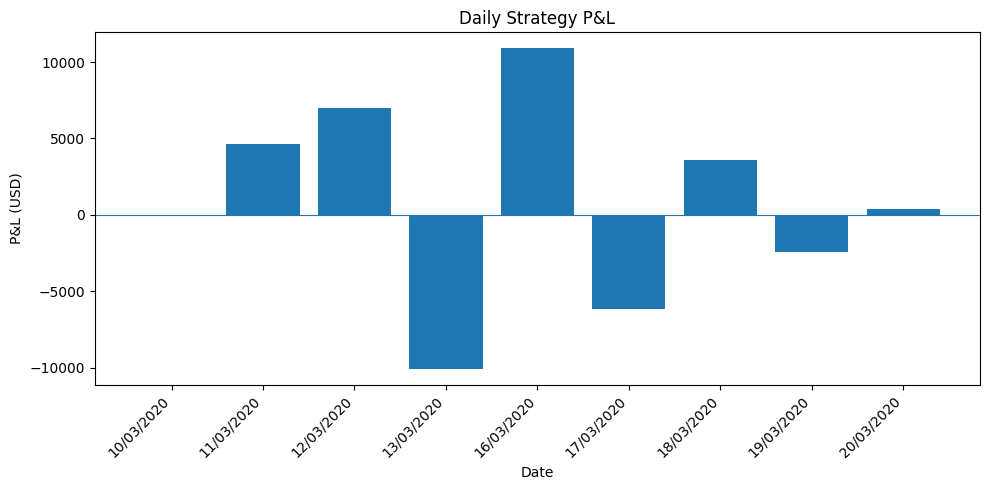

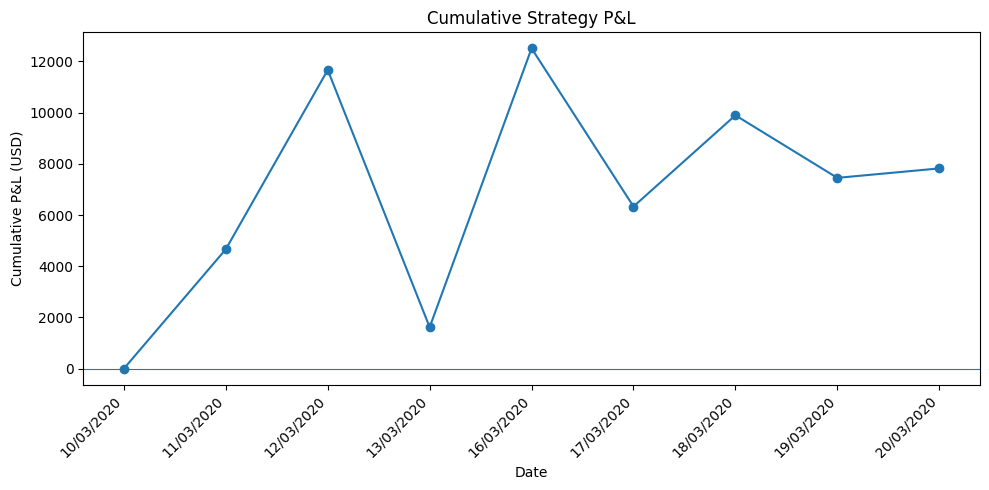

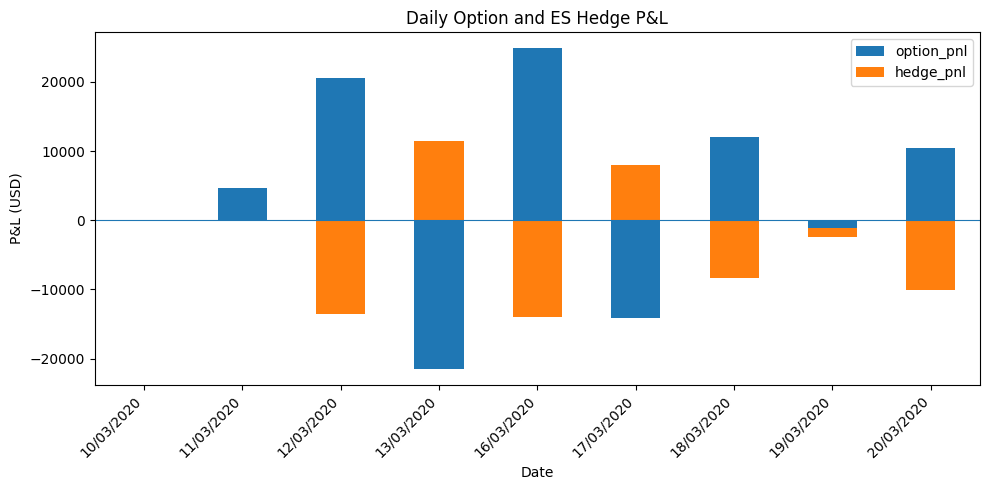

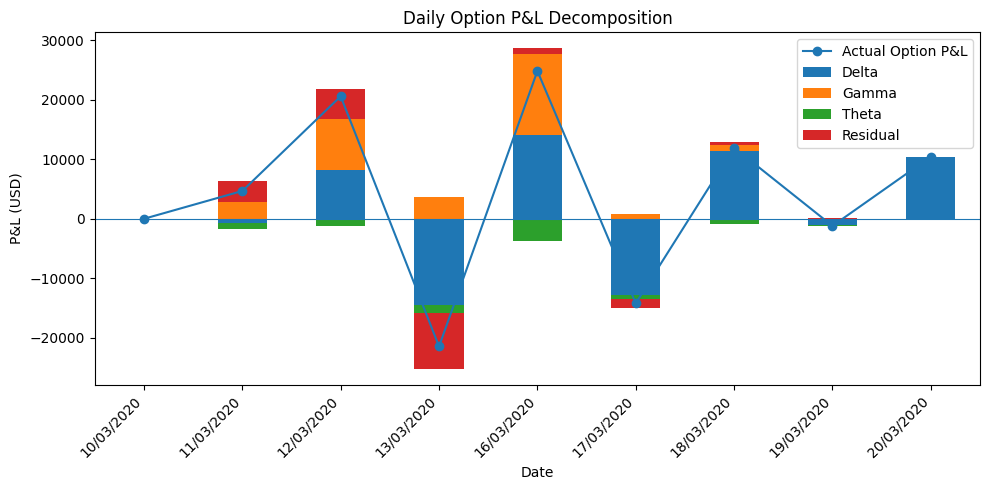

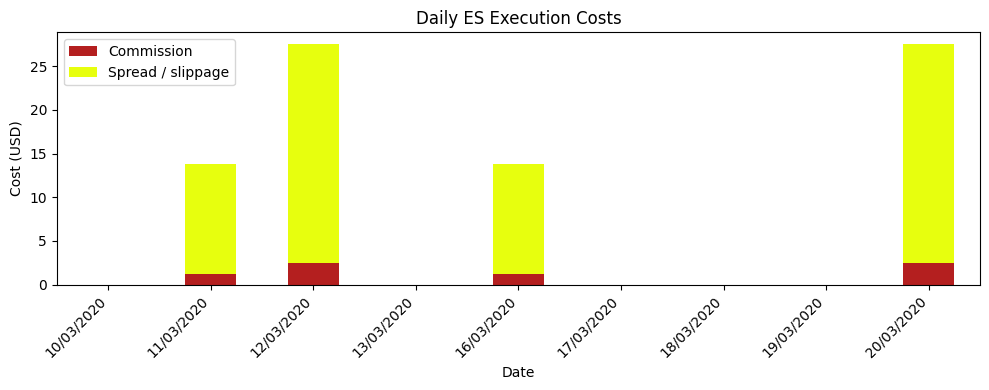

In [10]:
# Use trading observations only for plotting.
# Each actual backtest observation is equally spaced on the x-axis,
# so non-trading weekend dates do not create artificial gaps.
plot_x = np.arange(len(res))

plot_labels = [
    ts.strftime("%d/%m/%Y")
    for ts in res.index
]


# Daily strategy P&L
plt.figure(figsize=(10, 5))

plt.bar(
    plot_x,
    res["total_pnl"],
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.title("Daily Strategy P&L")
plt.xlabel("Date")
plt.ylabel("P&L (USD)")

plt.xticks(
    plot_x,
    plot_labels,
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()


# Cumulative strategy P&L
plt.figure(figsize=(10, 5))

plt.plot(
    plot_x,
    res["cum_pnl"],
    marker="o",
)

plt.axhline(
    0.0,
    linewidth=0.8,
)

plt.title("Cumulative Strategy P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (USD)")

plt.xticks(
    plot_x,
    plot_labels,
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()


# Core daily P&L components
pnl_components = res[
    ["option_pnl", "hedge_pnl"]
].copy()

pnl_components.index = plot_labels

ax = pnl_components.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
)

ax.axhline(
    0.0,
    linewidth=0.8,
)

ax.set_title("Daily Option and ES Hedge P&L")
ax.set_xlabel("Date")
ax.set_ylabel("P&L (USD)")

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

# Daily option P&L decomposition
option_components = res[
    [
        "delta_attribution",
        "gamma_attribution",
        "theta_attribution",
        "option_residual",
    ]
].copy()

option_components.columns = [
    "Delta",
    "Gamma",
    "Theta",
    "Residual",
]

option_components.index = plot_labels

ax = option_components.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
)

# Overlay actual option P&L to show reconciliation
ax.plot(
    plot_x,
    res["option_pnl"],
    marker="o",
    linewidth=1.5,
    label="Actual Option P&L",
)

ax.axhline(
    0.0,
    linewidth=0.8,
)

ax.set_title("Daily Option P&L Decomposition")
ax.set_xlabel("Date")
ax.set_ylabel("P&L (USD)")

plt.xticks(
    plot_x,
    plot_labels,
    rotation=45,
    ha="right",
)

ax.legend()

plt.tight_layout()
plt.show()


# Daily ES transaction costs
cost_components = res[
    ["commission", "execution_cost"]
].copy()

cost_components.columns = [
    "Commission",
    "Spread / slippage",
]

cost_components.index = plot_labels

ax = cost_components.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 4),
    color=["#b41f1f", "#e7ff0e"]
)

ax.set_title("Daily ES Execution Costs")
ax.set_xlabel("Date")
ax.set_ylabel("Cost (USD)")

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

## 8 Limitations

This notebook contains a more executable ES hedge. It retains core option valuation framework and uses the same historical test window. Therefore, it can be interpreted as a practical base-case.

Remaining limiations are as follows:

- **Implied Volatility Proxy:** VIX9D is used as the volatility input to the Black-Scholes model rather than strike-specific implied volatility for the selected SPX call and put.

- **Discrete Hedging:** Hedging only occurs at the available daily observations and is still subject to the same rehedge band (10%).

- **Hedge Timining:** SPX/VIX9D closing inputs & ES settlement prices do not have a common timestamp. Therefore, intraday execution timings are not modelled.

- **SPX and ES price conventions:** The option is marked using SPX closing levels while the hedge is valued using official ES settlement prices. Differences in timing and market conventions may introduce additional basis effects.

- **SPX–ES basis risk:** ES futures are used as a proxy hedge for SPX exposure. Changes in the futures basis can therefore cause hedge P&L to differ from the P&L implied by movements in the spot index alone.

- **Greek attribution:** Delta, gamma and theta are used to attribute the option-price change. The residual therefore contains the effects of changes in implied volatility and approximation error. It should not be interpreted as pure vega P&L.

- **Short stress-period sample:** The analysis covers a small number of observations during the very volatile March 2020 market environment. Results therefore illustrate the mechanics of gamma scalping under stressed conditions rather than providing evidence of long-run strategy performance.